# Graph Beckmann Flow for $\Wass_1$

This notebook generates `fig:w1-graph-transport-flow`.  On a finite graph with edge lengths $\ell_e$, the graph Beckmann formulation is
$$
    \Wass_{1,G}(\alpha,\beta)=\min_m\left\{\sum_{e\in E}\ell_e |m_e|:\ \operatorname{div}_G m=\alpha-\beta\right\}.
$$
The figure samples the graph vertices from a two-component Gaussian mixture, triangulates them with a Delaunay graph, and solves the finite-dimensional Beckmann linear program.  Red and blue disks mark the positive and negative parts of the signed source term, while violet arrows show the optimal edge flow.


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap, to_rgb
from matplotlib.patches import FancyArrowPatch
from scipy.optimize import linprog
from scipy.spatial import Delaunay

ROOT = Path.cwd()
if not (ROOT / "notebooks-figures").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "notebooks-figures"))

from figure_style import (
    RED, BLUE, VIOLET, ORANGE, GRAY, LIGHT_GRAY, BACKGROUND,
    DIRAC_MARKER_SIZE, MASS_MARKER_MIN_FACTOR, MASS_MARKER_MAX_FACTOR,
    TRANSPORT_LINE_MIN_WIDTH, POINT_EDGE_WIDTH,
    setup_matplotlib, figure_dir, save_pdf, remove_axes, padded_limits,
    interp_color,
)

setup_matplotlib()

NAME = "w1-graph-transport-flow"
OUT = figure_dir(NAME)


## A nonuniform Delaunay graph and localized signed masses

We sample vertices from two anisotropic Gaussian clouds, so the graph has visible density variations rather than a lattice structure.  Each Delaunay edge is oriented by increasing vertex index, and the signed flow is represented by positive and negative edge variables in a linear program.


In [2]:

rng = np.random.default_rng(715)

def sample_gaussian_cloud(mean, cov, count):
    return rng.multivariate_normal(np.asarray(mean, dtype=float), np.asarray(cov, dtype=float), count)

left = sample_gaussian_cloud(
    mean=(-0.86, -0.08),
    cov=[[0.115, 0.035], [0.035, 0.085]],
    count=38,
)
right = sample_gaussian_cloud(
    mean=(0.84, 0.16),
    cov=[[0.135, -0.050], [-0.050, 0.105]],
    count=34,
)
points = np.vstack([left, right])
points -= points.mean(axis=0, keepdims=True)
points[:, 0] *= 1.08
points[:, 1] *= 1.18
n = len(points)

tri = Delaunay(points)
edges = set()
for simplex in tri.simplices:
    for a in range(3):
        for b in range(a + 1, 3):
            edges.add(tuple(sorted((int(simplex[a]), int(simplex[b])))))
edges = sorted(edges)
lengths = np.array([np.linalg.norm(points[i] - points[j]) for i, j in edges])

source_center = np.array([-1.20, 0.34])
target_center = np.array([1.15, -0.20])
source_idx = np.argsort(np.linalg.norm(points - source_center, axis=1))[:6]
target_idx = np.argsort(np.linalg.norm(points - target_center, axis=1))[:6]
source_weights = np.exp(-3.8 * np.linalg.norm(points[source_idx] - source_center, axis=1) ** 2)
target_weights = np.exp(-3.6 * np.linalg.norm(points[target_idx] - target_center, axis=1) ** 2)
source_weights = source_weights / source_weights.sum()
target_weights = target_weights / target_weights.sum()

alpha = np.zeros(n)
beta = np.zeros(n)
alpha[source_idx] = source_weights
beta[target_idx] = target_weights
r = alpha - beta

incidence = np.zeros((n, len(edges)))
for e, (i, j) in enumerate(edges):
    # The edge is oriented i -> j.  This incidence convention gives
    # (div_G m)_i = outgoing flow - incoming flow, as in the paper.
    incidence[i, e] = 1.0
    incidence[j, e] = -1.0

assert abs(r.sum()) < 1e-14
assert np.linalg.matrix_rank(incidence) == n - 1  # connected graph

objective = np.r_[lengths, lengths]
constraints = np.c_[incidence, -incidence]
res = linprog(
    objective,
    A_eq=constraints[:-1],
    b_eq=r[:-1],
    bounds=[(0.0, None)] * (2 * len(edges)),
    method="highs",
)
if not res.success:
    raise RuntimeError(res.message)
flow = res.x[: len(edges)] - res.x[len(edges) :]
assert np.linalg.norm(incidence @ flow - r, ord=np.inf) < 1e-9
active_edges = np.flatnonzero(np.abs(flow) > 1e-9)
flow_cost = float(np.dot(lengths, np.abs(flow)))

# Independent check: solve the graph Kantorovich--Rubinstein dual
# max_f <f,r> subject to |f_i-f_j| <= ell_e, with f_0=0 fixing the gauge.
A_ub = np.vstack([incidence.T, -incidence.T])
b_ub = np.r_[lengths, lengths]
A_eq = np.zeros((1, n))
A_eq[0, 0] = 1.0
dual = linprog(
    -r,
    A_ub=A_ub,
    b_ub=b_ub,
    A_eq=A_eq,
    b_eq=np.zeros(1),
    bounds=[(None, None)] * n,
    method="highs",
)
if not dual.success:
    raise RuntimeError(dual.message)
dual_cost = -float(dual.fun)
assert abs(flow_cost - dual_cost) <= 1e-8 * max(1.0, flow_cost)
flow_cost, dual_cost, n, len(edges), len(active_edges)


(2.5087848415026373, 2.5087848415026373, 72, 202, 31)

## Exported panel

The book uses a single panel: the nonuniform triangulated graph, the signed masses, and the optimal edge flow.  Only circular markers are used for masses and vertices; arrow widths encode $\sqrt{|m_e|}$.


In [3]:

xlim_graph, ylim_graph = padded_limits(points, pad=0.075)


def draw_base_graph(ax, *, alpha_edges=0.55, lw=0.56):
    segments = [[points[i], points[j]] for i, j in edges]
    rgba = (*to_rgb("#1f1f1f"), alpha_edges)
    ax.add_collection(LineCollection(segments, colors=[rgba], linewidths=lw, zorder=0))
    ax.scatter(
        points[:, 0], points[:, 1],
        s=DIRAC_MARKER_SIZE * 0.16, marker="o",
        color="#5a5a5a", edgecolor="none", linewidth=0, zorder=1,
    )


def mass_sizes(weights):
    sizes = np.zeros_like(weights)
    mask = weights > 0
    if np.any(mask):
        sizes[mask] = DIRAC_MARKER_SIZE * (0.55 + 1.10 * weights[mask] / weights[mask].max())
    return sizes


def draw_masses(ax, *, alpha_scale=1.0):
    sa = mass_sizes(alpha) * alpha_scale
    sb = mass_sizes(beta) * alpha_scale
    ma = alpha > 0
    mb = beta > 0
    ax.scatter(points[ma, 0], points[ma, 1], s=sa[ma], marker="o", color=RED, edgecolor="none", linewidth=0, zorder=4)
    ax.scatter(points[mb, 0], points[mb, 1], s=sb[mb], marker="o", color=BLUE, edgecolor="none", linewidth=0, zorder=4)


def finish_graph(ax):
    ax.set_xlim(*xlim_graph)
    ax.set_ylim(*ylim_graph)
    ax.set_aspect("equal")
    remove_axes(ax)


fig, ax = plt.subplots(figsize=(3.20, 2.52))
draw_base_graph(ax, alpha_edges=0.62, lw=0.62)
max_flow = max(float(np.max(np.abs(flow))), 1e-15)
for e in active_edges:
    i, j = edges[e]
    val = flow[e]
    start, end = (i, j) if val > 0 else (j, i)
    p0 = points[start].copy()
    p1 = points[end].copy()
    d = p1 - p0
    ell = np.linalg.norm(d)
    if ell == 0:
        continue
    u = d / ell
    p0 = p0 + 0.045 * u
    p1 = p1 - 0.045 * u
    normalized = abs(val) / max_flow
    width = TRANSPORT_LINE_MIN_WIDTH + (1.85 - TRANSPORT_LINE_MIN_WIDTH) * np.sqrt(normalized)
    arrow = FancyArrowPatch(
        p0,
        p1,
        arrowstyle="-|>",
        mutation_scale=5.8 + 2.5 * np.sqrt(normalized),
        linewidth=width,
        color=VIOLET,
        alpha=min(0.34 + 0.62 * normalized, 0.94),
        shrinkA=0,
        shrinkB=0,
        zorder=3,
    )
    ax.add_patch(arrow)

draw_masses(ax, alpha_scale=0.82)
finish_graph(ax)
save_pdf(fig, OUT / "flow.pdf", pad_inches=0.040)
thumb_dir = ROOT / "notebooks-figures" / "thumbnails"
thumb_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(thumb_dir / f"{NAME}.png", dpi=190, bbox_inches="tight", pad_inches=0.035)
plt.close(fig)


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


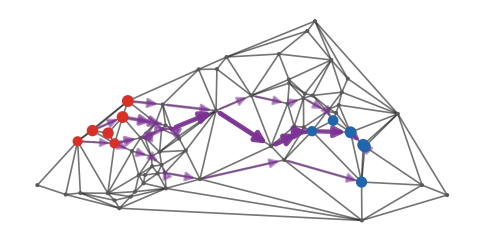

In [4]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/w1-graph-transport-flow.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/w1-graph-transport-flow.png")
display(Image(filename=str(_thumb)))
